# Phase 1:  Data Exploration and Initial Analysis

## 1.1 Initial data review

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
import numpy as np


In [17]:
df = pd.read_csv('football.csv')
df.head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season,Market_value,Transfer_fee
0,Luís Figo,Right Winger,27.0,FC Barcelona,LaLiga,Real Madrid,LaLiga,2000-2001,NaN,6.000000e+07
1,Hernán Crespo,Centre-Forward,25.0,Parma,Serie A,Lazio,Serie A,2000-2001,NaN,5.681000e+07
2,Marc Overmars,Left Winger,27.0,Arsenal,Premier League,FC Barcelona,LaLiga,2000-2001,NaN,4.000000e+07
3,Gabriel Batistuta,Centre-Forward,31.0,Fiorentina,Serie A,AS Rola,mhQdi,2000-2001,NaN,3.615000e+07
4,Nicolas Anelka,Centre-Forward,21.0,Real Madrid,LaLiga,Paris SG,Ligue 1,2000-2001,NaN,2.925040e+07


In [18]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 4700
Number of Columns: 10


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4700 entries, 0 to 4699
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          4660 non-null   object 
 1   Position      4667 non-null   object 
 2   Age           4616 non-null   float64
 3   Team_from     4663 non-null   object 
 4   League_from   4652 non-null   object 
 5   Team_to       4651 non-null   object 
 6   League_to     4666 non-null   object 
 7   Season        4647 non-null   object 
 8   Market_value  3379 non-null   float64
 9   Transfer_fee  4608 non-null   float64
dtypes: float64(3), object(7)
memory usage: 367.3+ KB


In [20]:
print("missing values for each column")
missing_values = df.isnull().sum()
print(missing_values)

missing values for each column
Name              40
Position          33
Age               84
Team_from         37
League_from       48
Team_to           49
League_to         34
Season            53
Market_value    1321
Transfer_fee      92
dtype: int64


In [21]:
# huge gap between top and buttom.
stats = df.describe()
print(stats)

               Age  Market_value  Transfer_fee
count  4616.000000  3.379000e+03  4.608000e+03
mean     25.971224  9.026841e+06  1.001174e+07
std      16.786169  1.070848e+07  1.300129e+07
min       0.000000  5.000000e+04  8.250000e+05
25%      22.000000  3.500000e+06  4.000000e+06
50%      24.000000  6.337435e+06  6.500000e+06
75%      27.000000  1.038545e+07  1.100000e+07
max     288.704043  2.780097e+08  2.654239e+08


## 1.2 data visualization

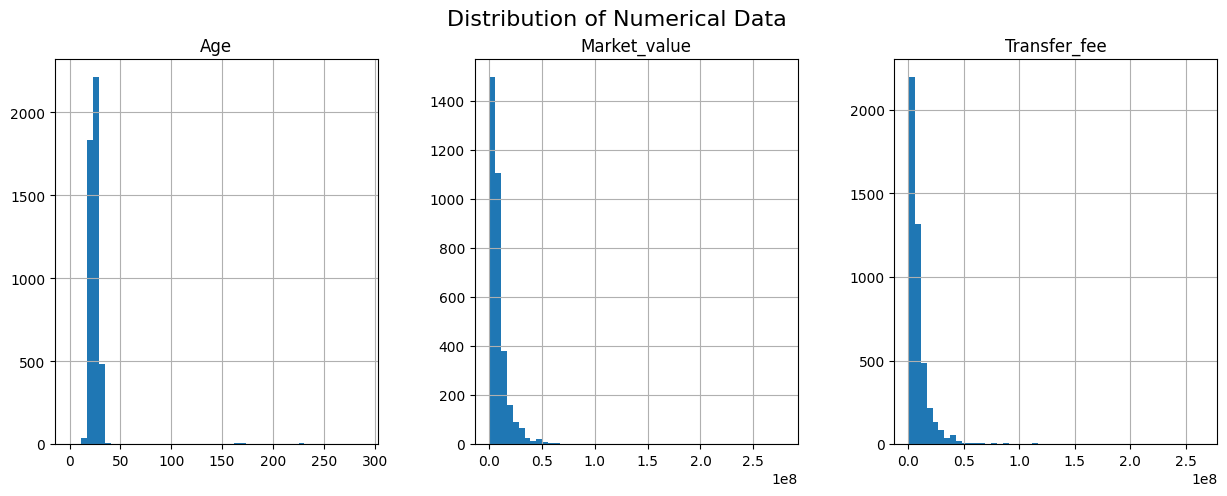

In [22]:
df[['Age', 'Market_value', 'Transfer_fee']].hist(bins=50, figsize=(15, 5), layout=(1, 3))
plt.suptitle('Distribution of Numerical Data', fontsize=16)
plt.show()

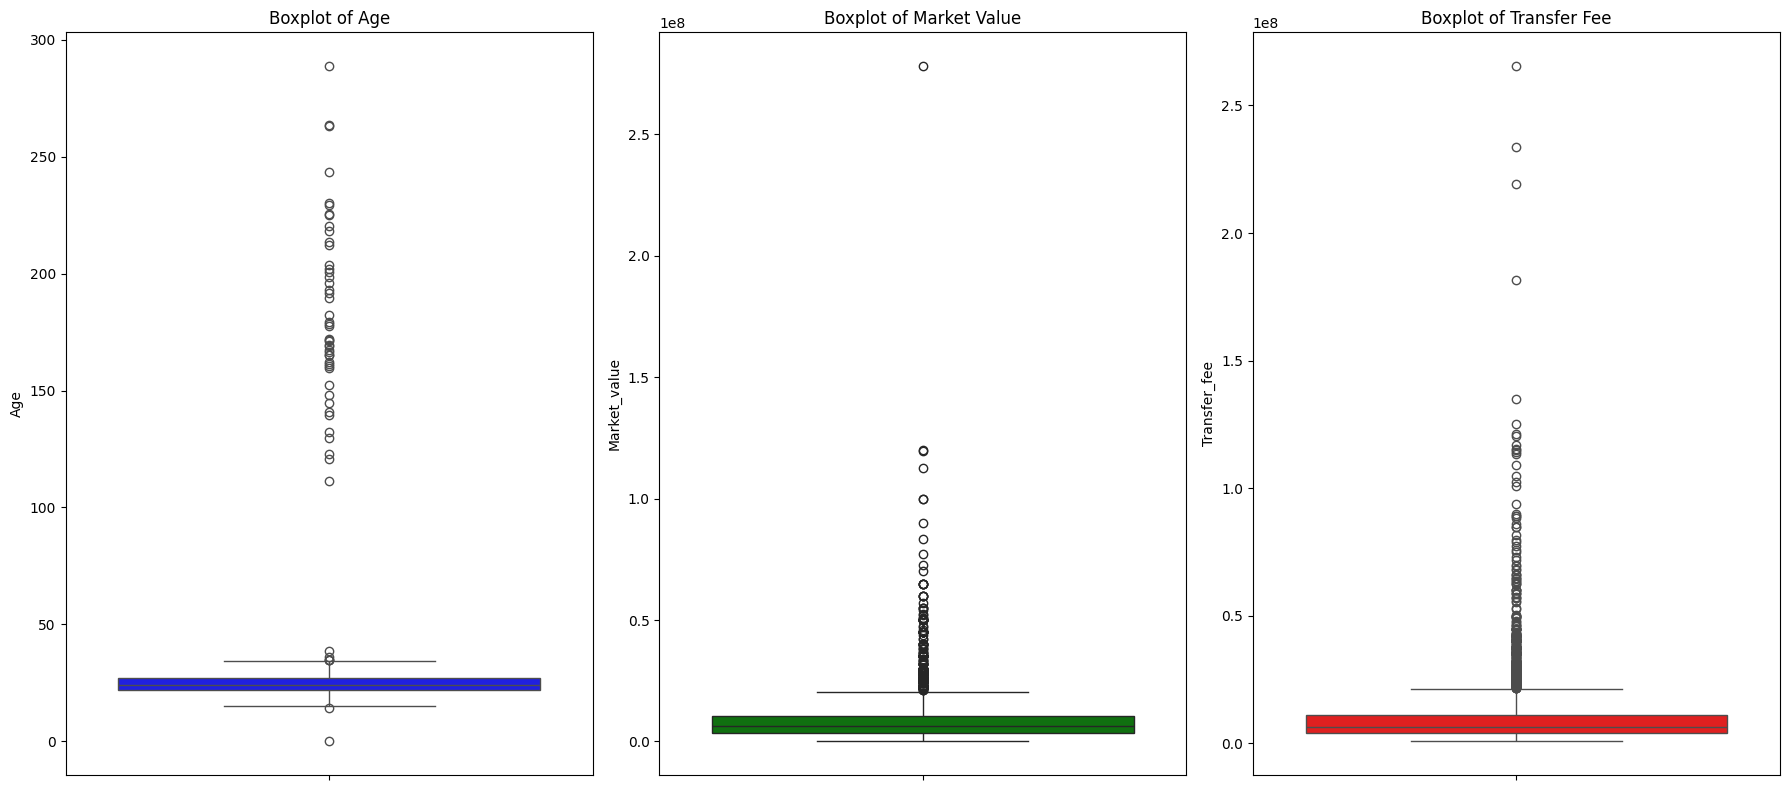

In [23]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['Age'], color='blue')
plt.title('Boxplot of Age')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Market_value'], color='green')
plt.title('Boxplot of Market Value')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Transfer_fee'], color='red')
plt.title('Boxplot of Transfer Fee')

plt.tight_layout()
plt.show()

C:\Users\sasan_wmsfg3b\AppData\Local\Temp\ipykernel_19596\1293088044.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='Reds_r')


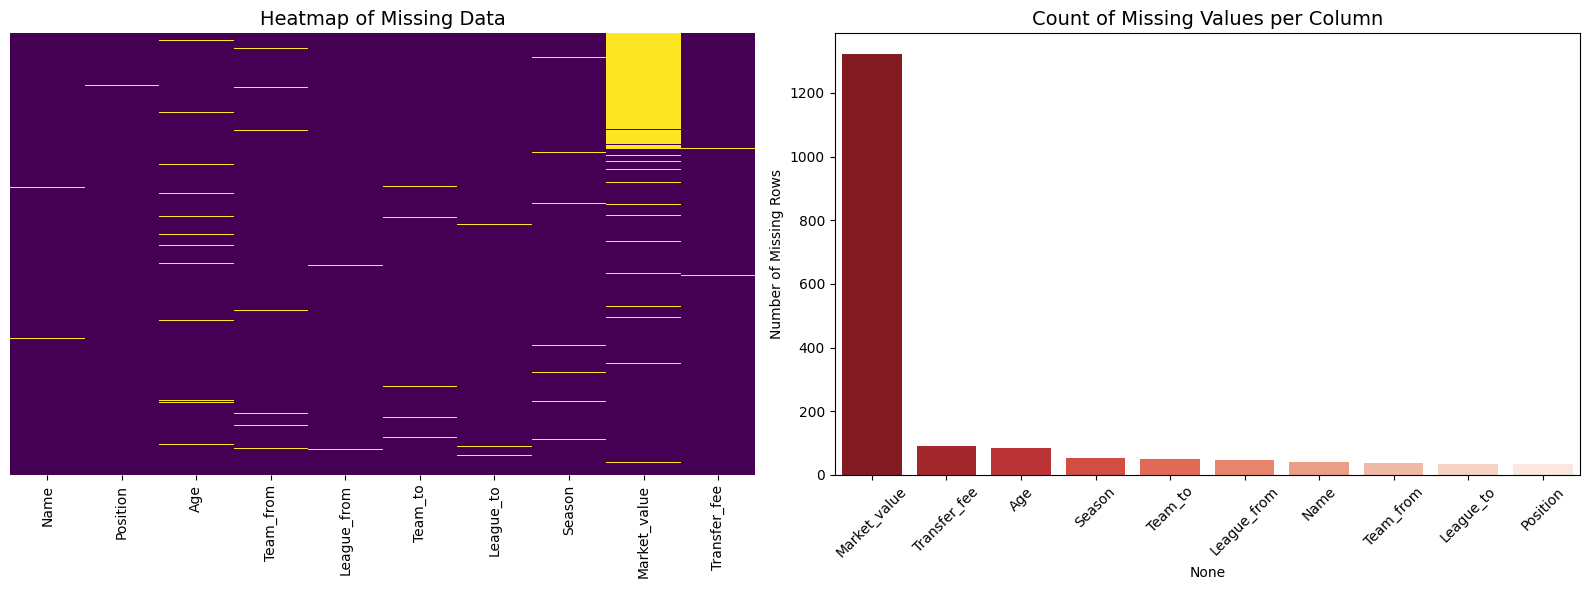

In [24]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Heatmap of Missing Data', fontsize=14)

plt.subplot(1, 2, 2)
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='Reds_r')
plt.title('Count of Missing Values per Column', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Number of Missing Rows')

plt.tight_layout()
plt.show()

## 1.3 Examining relationships between variables

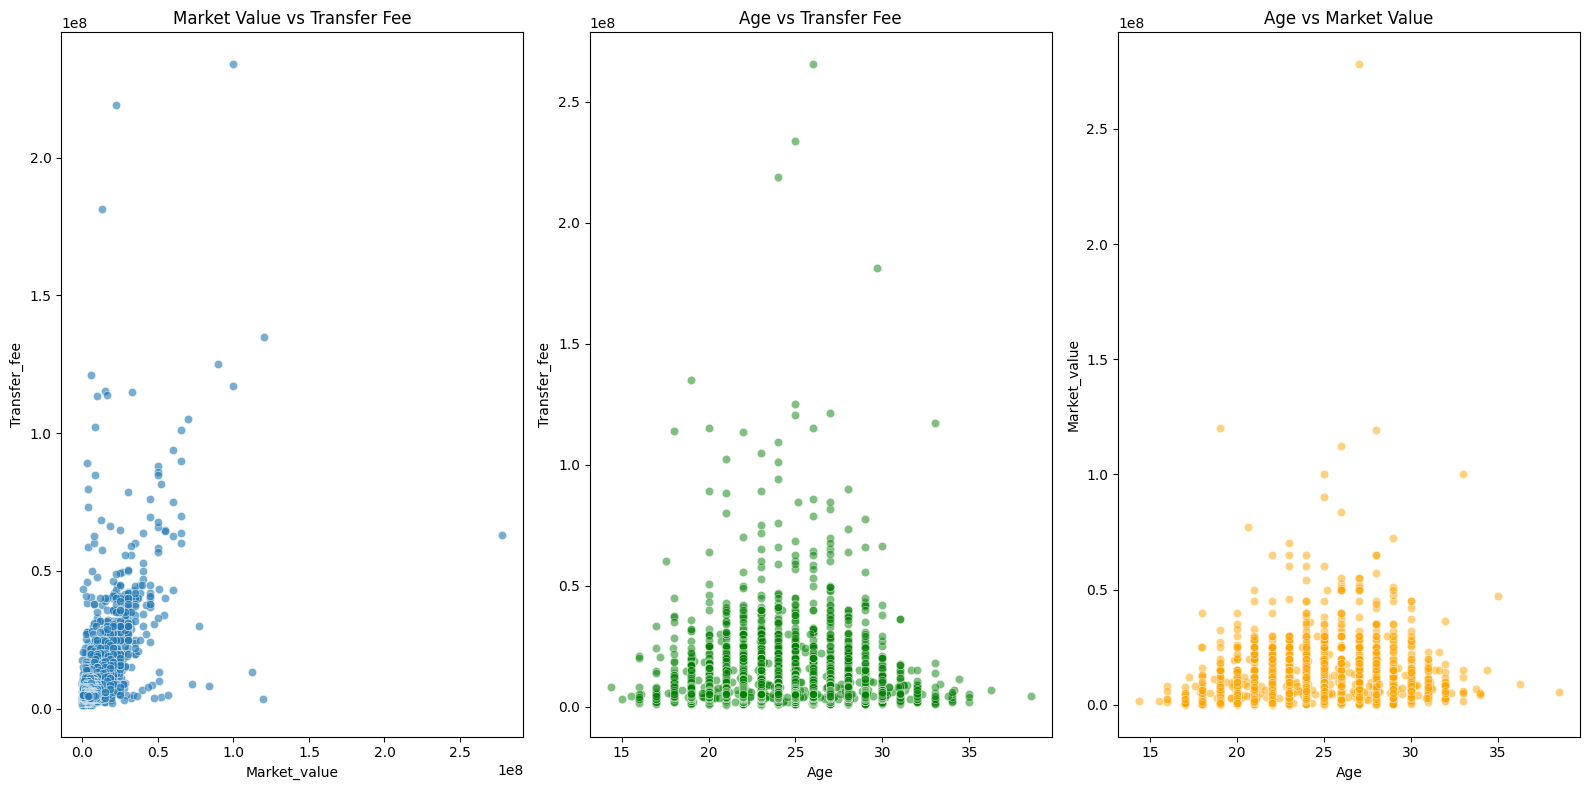

In [25]:
plt.figure(figsize=(16, 8))
temp_df = df[(df['Age'] > 0) & (df['Age'] < 100)]


plt.subplot(1, 3, 1)
sns.scatterplot(x=df['Market_value'], y=df['Transfer_fee'], alpha=0.6)
plt.title('Market Value vs Transfer Fee')

plt.subplot(1, 3, 2)
sns.scatterplot(x=temp_df['Age'], y=temp_df['Transfer_fee'], color='green', alpha=0.5)
plt.title('Age vs Transfer Fee')

plt.subplot(1, 3, 3)
sns.scatterplot(x=temp_df['Age'], y=temp_df['Market_value'], color='orange', alpha=0.5)
plt.title('Age vs Market Value')

plt.tight_layout()
plt.show()

Correlation between Market Value and Transfer Fee: 0.60
Interpretation: Strong Positive Relationship observed. Players with higher market value tend to have higher transfer fees.


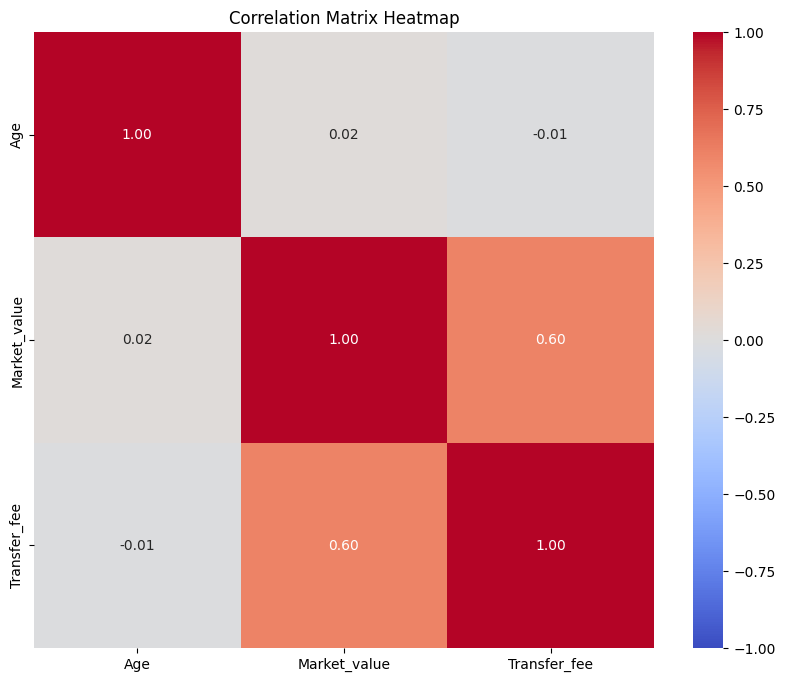

In [26]:
correlation_val = df['Market_value'].corr(df['Transfer_fee'])
print(f"Correlation between Market Value and Transfer Fee: {correlation_val:.2f}")
if correlation_val >= 0.6:
    print("Interpretation: Strong Positive Relationship observed. Players with higher market value tend to have higher transfer fees.")
else:
    print("Interpretation: Moderate to Weak relationship observed.")

numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

---
# Phase 2: Data Quality Assessment

## 2.1 Defining and calculating data quality metrics

<div dir="rtl" style="text-align: right; line-height: 1.6;">

<h3>۱. دقت (Accuracy)</h3>
<ul>
  <li><strong>تعریف:</strong> این معیار نشان می‌دهد که داده‌های ذخیره شده تا چه حد با واقعیت (دنیای واقعی) مطابقت دارند.</li>
  <li><strong>در پروژه من:</strong> به عنوان مثال، در ستون Age، وجود مقدار <code>288</code> یا <code>0</code> دقت داده‌ها را پایین می‌آورد، زیرا هیچ بازیکن فوتبالی در دنیای واقعی ۲۸۸ ساله یا ۰ ساله نیست. محاسبه دقت یعنی بررسی اینکه چه درصدی از بازیکنان سن واقعی و منطقی (مثلاً بین ۱۵ تا ۴۵ سال) دارند.</li>
</ul>

<h3>۲. کامل بودن (Completeness)</h3>
<ul>
  <li><strong>تعریف:</strong> این معیار به درصدی از داده‌ها اشاره دارد که در دیتاست موجود هستند و خالی (Null/Missing) نیستند.</li>
  <li><strong>در پروژه من:</strong> ما مشاهده می شود که ستون <code>Market_value</code> دارای مقادیر  NaN زیادی است. اگر ۳۰٪ از سلول‌های این ستون خالی باشند، امتیاز «کامل بودن» برای این ستون ۷۰٪ خواهد بود. هدف من داشتن دیتاستی با کمترین مقدار گمشده است.</li>
</ul>

<h3>۳. معتبر بودن (Validity)</h3>
<ul>
  <li><strong>تعریف:</strong> این معیار بررسی می‌کند که آیا داده‌ها از نظر فرمت، نوع (Type) و قواعد نحوی (Syntax) صحیح هستند یا خیر.</li>
  <li><strong>در پروژه من:</strong> مبلغ قرارداد (<code>Transfer_fee</code>) باید همواره یک عدد مثبت باشد. اگر عددی منفی باشد یا به جای عدد، حروف متنی نوشته شده باشد، آن داده معتبر نیست (Invalid). همچنین فرمت ستون فصل (<code>Season</code>) باید به صورت استاندارد (مثلاً "2000-2001") باشد.</li>
</ul>

<h3>۴. به‌روز بودن (Currentness / Timeliness)</h3>
<ul>
  <li><strong>تعریف:</strong> این معیار نشان می‌دهد که داده‌ها تا چه حد جدید هستند و آیا برای زمان حال قابل استفاده‌اند یا خیر.</li>
  <li><strong>در پروژه من:</strong> از آنجا که این یک دیتاست تاریخی است، «به‌روز بودن» به این معنی است که بازه زمانی داده‌ها (ستون Season) مشخص و قابل استناد باشد تا بتوانیم تحلیل روند (Trend Analysis) درستی انجام دهیم.</li>
</ul>

<h3>۵. سازگاری (Consistency)</h3>
<ul>
  <li><strong>تعریف:</strong> این معیار به معنای عدم وجود تناقض در داده‌هاست. داده‌ها باید در تمام بخش‌های پایگاه داده یکپارچه باشند.</li>
  <li><strong>در پروژه من:</strong> مهم‌ترین فاکتور سازگاری، عدم وجود «داده‌های تکراری» (Duplicates) است. اگر اطلاعات انتقال یک بازیکن خاص دقیقاً دو بار در دیتاست تکرار شده باشد، ناسازگاری ایجاد شده و باعث خطا در محاسبات آماری می‌شود.</li>
</ul>

</div>

In [27]:
print("DATA QUALITY STATISTICS REPORT")
print(f"Total Rows in Dataset: {df.shape[0]}")
print("\n")

name_garbage = df['Name'].str.contains(r'[\d@#\$%\^&\*]', regex=True, na=False)

age_errors = df[(df['Age'] < 15) | (df['Age'] > 45)]
count_age_errors = len(age_errors)

valid_positions = [
    'Goalkeeper', 'Centre-Back', 'Left-Back', 'Right-Back', 
    'Defensive Midfield', 'Central Midfield', 'Attacking Midfield', 
    'Left Winger', 'Right Winger', 'Centre-Forward', 'Second Striker',
    'Midfielder', 'Defender', 'Forward', 'Sweeper'
]
unknown_positions = df[~df['Position'].isin(valid_positions) & df['Position'].notnull()]

short_teams_from = df[df['Team_from'].str.len() < 3]
short_teams_to = df[df['Team_to'].str.len() < 3]
short_leagues_from = df[df['League_from'].str.len() < 3]
short_leagues_to = df[df['League_to'].str.len() < 3]


print(f"1. ACCURACY:")
print(f"   - Accuracy for Name: {(len(df['Name'])-len(name_garbage))/len(df['Name'])}")
print(f"   - Accuracy for position: {(len(df['Position'])-len(unknown_positions))/len(df['Position'])}")
print(f"   - Accuracy for age: {(len(df['Age'])-count_age_errors)/len(df['Age'])}")
print(f"   - Accuracy for TeamFrom: {(len(df['Team_from'])-len(short_teams_from))/len(df['Team_from'])}")
print(f"   - Accuracy for LeagueFrom: {(len(df['League_from'])-len(short_leagues_from))/len(df['League_from'])}")
print(f"   - Accuracy for TeamTo: {(len(df['Team_to'])-len(short_teams_from))/len(df['Team_to'])}")
print(f"   - Accuracy for LeagueTo: {(len(df['League_to'])-len(short_leagues_from))/len(df['League_to'])}")


total_cells = df.size
total_missing_cells = df.isnull().sum().sum()
missing_market_value = df['Market_value'].isnull().sum()
print(f"\n2. COMPLETENESS:")
print(f"   - Total Missing Cells: {total_missing_cells}")
print(f"   - Missing Name: {(df['Name'].isnull().sum()/df['Name'].count()):.2f} %")
print(f"   - Missing Age: {(df['Age'].isnull().sum()/df['Age'].count()):.2f} %")
print(f"   - Missing position: {(df['Position'].isnull().sum()/df['Position'].count()):.2f} %")
print(f"   - Missing teamFrom: {(df['Team_from'].isnull().sum()/df['Team_from'].count()):.2f} %")
print(f"   - Missing leagueFrom: {(df['League_from'].isnull().sum()/df['League_from'].count()):.2f} %")
print(f"   - Missing teamTo: {(df['Team_to'].isnull().sum()/df['Team_to'].count()):.2f} %")
print(f"   - Missing leagueTo: {(df['League_to'].isnull().sum()/df['League_to'].count()):.2f} %")
print(f"   - Missing Transfer_fee: {(df['Transfer_fee'].isnull().sum()/df['Transfer_fee'].count()):.2f} %")
print(f"   - Missing Market_value: {(missing_market_value/df['Market_value'].count()):.2f} %")


negative_fees = len(df[df['Transfer_fee'] < 0])
negative_value = len(df[df['Market_value'] < 0])

valid_season_pattern = r'^\d{4}-\d{4}$'
valid_seasons_mask = df['Season'].astype(str).str.match(valid_season_pattern)
invalid_seasons_count = df.shape[0] - valid_seasons_mask.sum()

print(f"\n3. VALIDITY & CURRENTNESS:")
print(f"   - Negative Transfer Fees (Count): {negative_fees}")
print(f"   - Negative Market Value (Count): {negative_value}")
print(f"   - Invalid Season Formats (Count): {invalid_seasons_count}")

duplicate_rows = df.duplicated().sum()
print(f"\n4. CONSISTENCY:")
print(f"   - Duplicate Rows Found: {duplicate_rows}")

DATA QUALITY STATISTICS REPORT
Total Rows in Dataset: 4700


1. ACCURACY:
   - Accuracy for Name: 0.0
   - Accuracy for position: 0.9178723404255319
   - Accuracy for age: 0.9895744680851064
   - Accuracy for TeamFrom: 1.0
   - Accuracy for LeagueFrom: 1.0
   - Accuracy for TeamTo: 1.0
   - Accuracy for LeagueTo: 1.0

2. COMPLETENESS:
   - Total Missing Cells: 1791
   - Missing Name: 0.01 %
   - Missing Age: 0.02 %
   - Missing position: 0.01 %
   - Missing teamFrom: 0.01 %
   - Missing leagueFrom: 0.01 %
   - Missing teamTo: 0.01 %
   - Missing leagueTo: 0.01 %
   - Missing Transfer_fee: 0.02 %
   - Missing Market_value: 0.39 %

3. VALIDITY & CURRENTNESS:
   - Negative Transfer Fees (Count): 0
   - Negative Market Value (Count): 0
   - Invalid Season Formats (Count): 336

4. CONSISTENCY:
   - Duplicate Rows Found: 0


## 2.2 Identify data quality problems

In [28]:
print("DETAILED COLUMN QUALITY AUDIT\n")

# 1. COLUMN: NAME
missing_names = df['Name'].isnull().sum()
invalid_name_pattern = r'[\d@#\$%\^&\*]'
invalid_names = df[df['Name'].str.contains(invalid_name_pattern, regex=True, na=False)]

print(f"[Name] Missing Values: {missing_names}")
print(f"[Name] Rows with numbers or special symbols: {len(invalid_names)}")
if len(invalid_names) > 0:
    print(f"   -> Examples: {invalid_names['Name'].head(3).tolist()}")

# 2. COLUMN: AGE
missing_age = df['Age'].isnull().sum()

if pd.api.types.is_numeric_dtype(df['Age']):
    non_numeric_age_count = 0 
else:
    non_numeric_age_count = df['Age'].astype(str).str.contains(r'[^0-9\.]', regex=True).sum()

decimal_age_count = (df['Age'].dropna() % 1 != 0).sum()

age_outliers = df[(df['Age'] < 15) | (df['Age'] > 50)]

print(f"\n[Age] Missing Values: {missing_age}")
print(f"[Age] Rows with non-numeric chars (@#$ etc): {non_numeric_age_count}")
print(f"[Age] Rows with decimal values (Floats): {decimal_age_count}")
print(f"[Age] Impossible Ages (<15 or >50): {len(age_outliers)} rows")
if len(age_outliers) > 0:
    print(f"   -> Examples: {age_outliers['Age'].unique().tolist()}")

# 3. COLUMN: POSITION
valid_positions = [
    'Goalkeeper', 'Centre-Back', 'Left-Back', 'Right-Back', 
    'Defensive Midfield', 'Central Midfield', 'Attacking Midfield', 
    'Left Winger', 'Right Winger', 'Centre-Forward', 'Second Striker',
    'Midfielder', 'Defender', 'Forward', 'Sweeper'
]

missing_pos = df['Position'].isnull().sum()
unknown_pos = df[~df['Position'].isin(valid_positions) & df['Position'].notnull()]
garbage_pos = df[df['Position'].astype(str).str.contains(r'[\d@#\$%\^&\*]', regex=True, na=False)]

print(f"\n[Position] Missing values: {missing_pos}")
print(f"[Position] Unknown Positions (Not in valid list): {len(unknown_pos)}")
print(f"[Position] Rows with numbers or special symbols (@#$ etc): {len(garbage_pos)}")

if len(unknown_pos) > 0:
    print(f"   -> Examples of Unknown/Invalid: {unknown_pos['Position'].unique().tolist()}")

# 4. COLUMNS: LEAGUE FROM/TO & TEAM FROM/TO
target_cols = ['League_from', 'League_to', 'Team_from', 'Team_to']
invalid_text_pattern = r'[\d@#\$%\^&\*]'

print(f"\n[Leagues & Teams] Detailed Audit:")

for col in target_cols:
    if col in df.columns:
        missing_count = df[col].isnull().sum()
        invalid_rows = df[df[col].astype(str).str.contains(invalid_text_pattern, regex=True, na=False)]
        
        print(f"   -- {col} --")
        print(f"      Missing Values: {missing_count}")
        print(f"      Rows with numbers or special symbols: {len(invalid_rows)}")
        
        if len(invalid_rows) > 0:
            print(f"      -> Examples: {invalid_rows[col].unique()[:3].tolist()}")
    else:
        print(f"   -- {col} NOT FOUND in DataFrame --")

# 5. COLUMN: SEASON
missing_seasons = df['Season'].isnull().sum()
garbage_seasons = df[df['Season'].astype(str).str.contains(r'[^0-9-]', regex=True, na=False)]

valid_format_rows = df[df['Season'].astype(str).str.match(r'^\d{4}-\d{4}$', na=False)].copy()
split_seasons = valid_format_rows['Season'].str.split('-', expand=True).astype(int)
logic_errors = valid_format_rows[split_seasons[0] >= split_seasons[1]]

print(f"\n[Season] Missing Values: {missing_seasons}")
print(f"[Season] Rows with invalid chars (not 0-9 or '-'): {len(garbage_seasons)}")
print(f"[Season] Rows with logic error (Start Year >= End Year): {len(logic_errors)}")

if len(garbage_seasons) > 0:
    print(f"   -> Examples of invalid chars: {garbage_seasons['Season'].unique()[:3].tolist()}")
if len(logic_errors) > 0:
    print(f"   -> Examples of logic errors: {logic_errors['Season'].unique()[:3].tolist()}")

# 6. COLUMN: MARKET_VALUE
missing_mv = df['Market_value'].isnull().sum()
print(f"\n[Market_value] Missing Values: {missing_mv} ({missing_mv/len(df)*100:.1f}%)")
print(f"[Market_value] Negative Values: {negative_value}")


# 7. COLUMN: TRANSFER_FEE
missing_tf = df['Transfer_fee'].isnull().sum()
print(f"\n[Transfer_fee] Missing Values: {missing_tf} ({missing_tf/len(df)*100:.1f}%)")
print(f"[Transfer_fee] Negative Values: {negative_fees}")

print("\n=== END OF AUDIT ===")

DETAILED COLUMN QUALITY AUDIT

[Name] Missing Values: 40
[Name] Rows with numbers or special symbols: 57
   -> Examples: ['nlr3H', 'xCE7y', '4DJBL']

[Age] Missing Values: 84
[Age] Rows with non-numeric chars (@#$ etc): 0
[Age] Rows with decimal values (Floats): 232
[Age] Impossible Ages (<15 or >50): 49 rows
   -> Examples: [129.76185367702797, 0.0, 200.4790967215486, 165.27635677717558, 195.79584950678057, 162.03506184924635, 167.20748232955918, 263.0002778575076, 132.08387091009132, 191.6479095397681, 169.11510445637143, 218.16177191069917, 201.96081280996285, 220.20245191608973, 230.3661214270035, 171.5070897032562, 140.88495986849415, 172.06219790855675, 111.19979175029268, 159.72356471545015, 177.5709499277201, 166.3302364129209, 243.4060721729823, 263.4972190291763, 189.70778339042968, 122.79673840203972, 212.1269676244085, 148.02655928543112, 182.44543630334897, 225.21187641140995, 139.63871314388453, 203.6178558474855, 288.7040427417844, 160.39635656270778, 120.92005639374878,

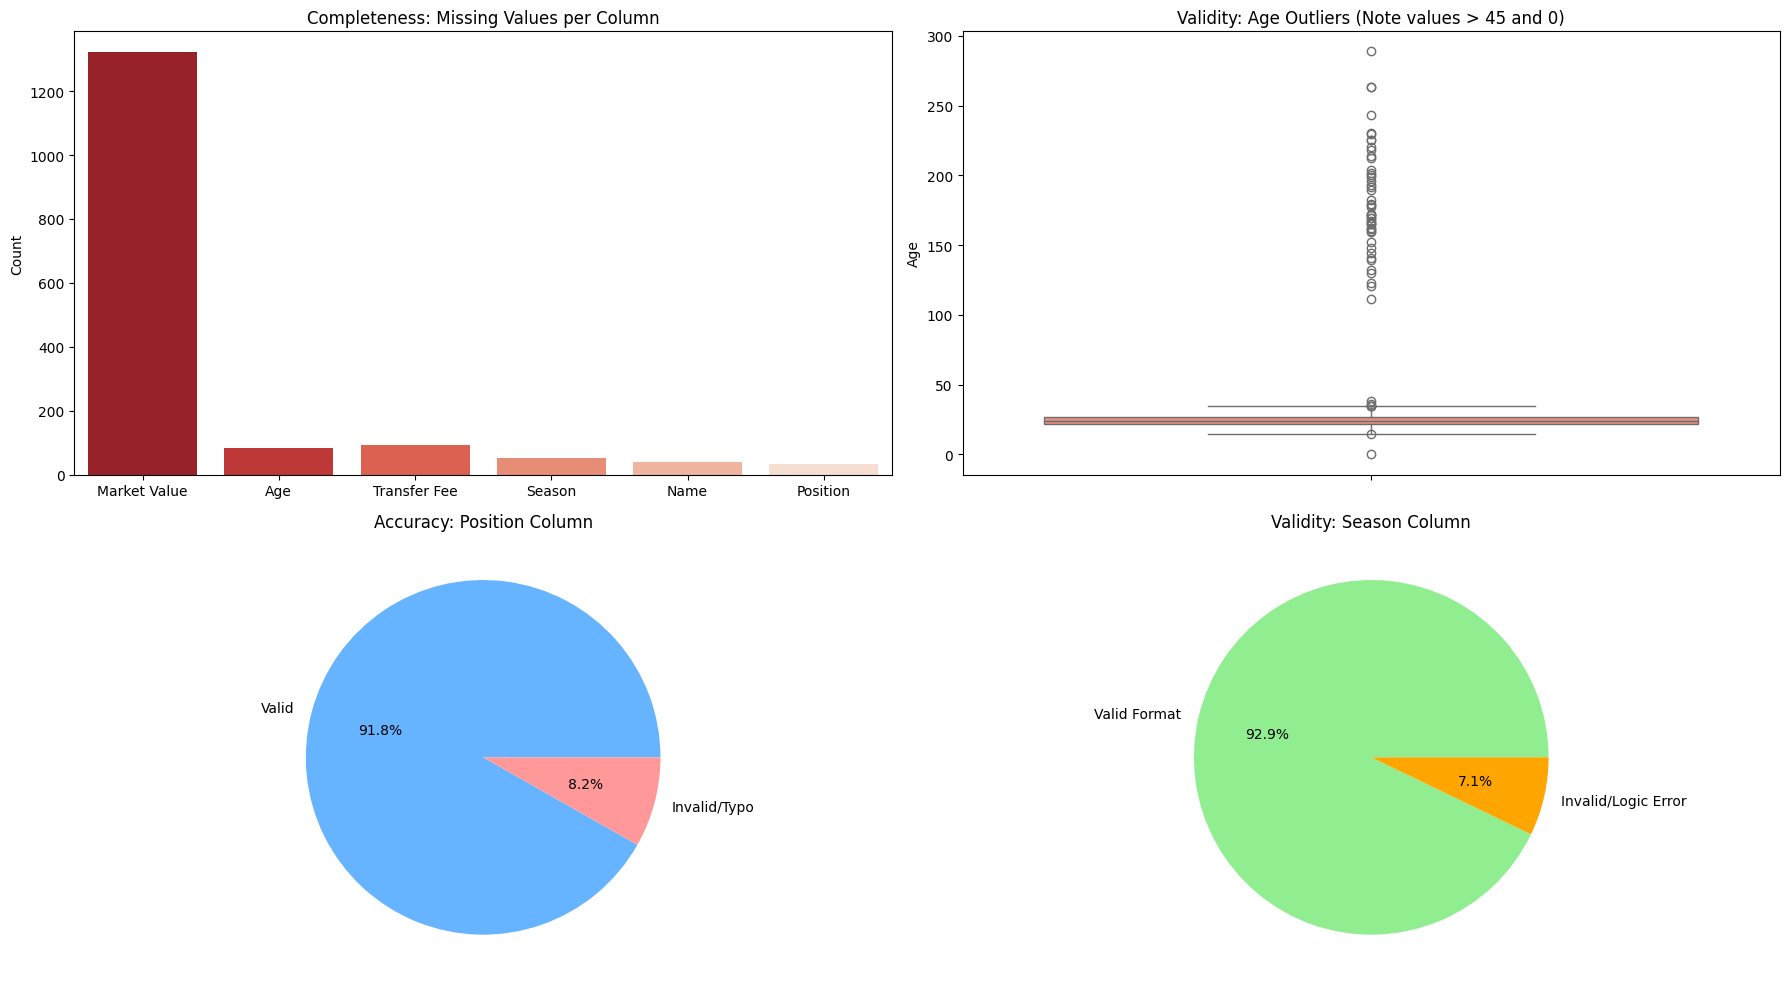

In [29]:
missing_data = {
    'Market Value': df['Market_value'].isnull().sum(),
    'Age': df['Age'].isnull().sum(),
    'Transfer Fee': df['Transfer_fee'].isnull().sum(),
    'Season': df['Season'].isnull().sum(),
    'Name': df['Name'].isnull().sum(),
    'Position': df['Position'].isnull().sum(),
}

plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1)
sns.barplot(
    x=list(missing_data.keys()), 
    y=list(missing_data.values()), 
    hue=list(missing_data.keys()), 
    legend=False, 
    palette='Reds_r'
)
plt.title('Completeness: Missing Values per Column')
plt.ylabel('Count')


plt.subplot(2, 2, 2)
sns.boxplot(y=df['Age'], color='salmon')
plt.title('Validity: Age Outliers (Note values > 45 and 0)')


plt.subplot(2, 2, 3)
valid_positions_list = [
    'Goalkeeper', 'Centre-Back', 'Left-Back', 'Right-Back', 
    'Defensive Midfield', 'Central Midfield', 'Attacking Midfield', 
    'Left Winger', 'Right Winger', 'Centre-Forward', 'Second Striker',
    'Midfielder', 'Defender', 'Forward', 'Sweeper'
]
invalid_pos_count = len(df[~df['Position'].astype(str).str.strip().isin(valid_positions_list) & df['Position'].notnull()])
valid_pos_count = len(df) - invalid_pos_count

plt.pie([valid_pos_count, invalid_pos_count], labels=['Valid', 'Invalid/Typo'], autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'])
plt.title('Accuracy: Position Column')

plt.subplot(2, 2, 4)
invalid_season_format = (~df['Season'].astype(str).str.match(r'^\d{4}-\d{4}$', na=False)).sum()
valid_season_count = len(df) - invalid_season_format

plt.pie([valid_season_count, invalid_season_format], labels=['Valid Format', 'Invalid/Logic Error'], autopct='%1.1f%%', colors=['lightgreen', 'orange'])
plt.title('Validity: Season Column')

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right; line-height: 1.8;">

<h2>گزارش تفصیلی کیفیت داده‌ها (Data Quality Report)</h2>
<p>این گزارش بر اساس ممیزی دقیق ستون‌ها (Column Audit) و تحلیل بصری نمودارها تهیه شده است. مشکلات شناسایی شده در جدول زیر خلاصه شده‌اند:</p>

<hr>

<h3>۱. تحلیل ستون‌های هویتی (Name, Age, Position)</h3>

<h4>الف) نام بازیکن (Name)</h4>
<ul>
  <li><strong>مشکل:</strong> وجود کاراکترهای غیرمجاز و داده‌های خراب.</li>
  <li><strong>شواهد آماری:</strong> ۵۷ رکورد حاوی اعداد یا کاراکترهای خاص (مانند <code>xCE7y</code>) هستند که نشان‌دهنده خطای سیستم یا انکدینگ است. ۴۰ رکورد نیز کاملاً خالی هستند.</li>
</ul>

<h4>ب) سن (Age) </h4>
<ul>
  <li><strong>مشکل:</strong> داده‌های پرت و فرمت اعشاری.</li>
  <li><strong>شواهد آماری:</strong>
    <ul>
      <li><strong>۴۹ رکورد غیرمنطقی:</strong> سنین بالای ۵۰ سال ( تا ۲۸۸ سال) و سن ۰.</li>
      <li><strong>۲۳۲ رکورد اعشاری:</strong> اعدادی مانند <code>129.76</code> که نشان‌دهنده خطای محاسباتی یا نرمال‌سازی غلط در دیتابیس مرجع است.</li>
    </ul>
  </li>
</ul>

<h4>ج) پست بازی (Position) </h4>
<ul>
  <li><strong>مشکل:</strong> غلط‌های املایی فراوان (Typos).</li>
  <li><strong>شواهد آماری:</strong> ۳۸۶ رکورد دارای مقادیری خارج از لیست استاندارد هستند. مثال‌هایی مانند <code>heft Winger</code> (به جای Left) یا <code>Goalkeeeer</code> نشان‌دهنده خطای تایپی یا OCR است.</li>
</ul>

<hr>

<h3>۲. تحلیل ستون‌های دسته‌بندی (Leagues, Teams, Season)</h3>

<h4>الف) لیگ‌ها و تیم‌ها (Leagues & Teams)</h4>
<ul>
  <li><strong>مشکل:</strong> ترکیب متن معتبر با داده‌های خراب (Garbage Text).</li>
  <li><strong>تحلیل:</strong> اسکریپت بازرسی، ۹۳۴ مورد را در <code>League_from</code> علامت‌گذاری کرد.
    <ul>
      <li>برخی موارد معتبر هستند (مانند <code>Ligue 1</code> که عدد دارد).</li>
      <li>برخی موارد خراب هستند (مانند <code>TTZi7</code> یا <code>0xvNK</code>).</li>
    </ul>
  </li>
  <li><strong>اقدام:</strong> در مرحله پاکسازی باید فقط متون بی‌معنی حذف شوند، نه لیگ‌هایی که ذاتاً عدد دارند.</li>
</ul>

<h4>ب) فصل (Season) </h4>
<ul>
  <li><strong>مشکل:</strong> فرمت نامعتبر.</li>
  <li><strong>شواهد آماری:</strong> ۳۳۶ رکورد (حدود ۷٪) فرمت استاندارد <code>YYYY-YYYY</code> را رعایت نکرده‌اند. وجود مقادیری مثل <code>nan</code> یا کاراکترهای درهم‌ریخته مانع از تحلیل زمانی می‌شود.</li>
</ul>

<hr>

<h3>۳. تحلیل ستون‌های مالی (Financial Columns)</h3>

<h4>الف) ارزش بازار (Market_value) </h4>
<ul>
  <li><strong>مشکل:</strong> عدم کامل بودن (Completeness).</li>
  <li><strong>شواهد آماری:</strong> ۱۳۲۱ رکورد (۲۸.۱٪) فاقد ارزش بازار هستند. این بزرگترین چالش دیتاست برای پیش‌بینی قیمت است.</li>
</ul>

<h4>ب) مبلغ انتقال (Transfer_fee)</h4>
<ul>
  <li><strong>وضعیت:</strong> پایدار. تنها ۲٪ داده گمشده دارد و هیچ مقدار منفی (Negative) مشاهده نشد.</li>
</ul>

<hr>

<h3>نتیجه‌گیری نهایی</h3>
<p>دیتاست دارای نویز (Noise) زیادی در ستون‌های متنی و سن است. استراتژی پاکسازی در فاز بعدی باید بر روی <strong>حذف داده‌های پرت سن</strong>، <strong>اصلاح غلط‌های املایی پوزیشن</strong> و <strong>پر کردن ارزش‌های بازار گمشده</strong> متمرکز شود.</p>

</div>

## 2.3 Providing solutions to improve data quality

<div dir="rtl" style="text-align: right; line-height: 1.8;">

<p>با توجه به نتایج ممیزی دقیق (Detailed Audit)، استراتژی پاکسازی برای تک‌تک ستون‌ها به شرح زیر تدوین شده است:</p>

<table border="1" style="border-collapse: collapse; width: 100%;"> <tr style="background-color: #f2f2f2;"> <th>ستون (Column)</th> <th>مشکلات شناسایی شده</th> <th>استراتژی پاکسازی (Action Plan)</th> </tr> <tr> <td><strong>Name</strong></td> <td>۴۰ مقدار گمشده، ۵۷ نام حاوی عدد/کاراکتر (مانند <code>xCE7y</code>).</td> <td><strong>حذف (Drop):</strong> نام‌های گمشده یا نام‌هایی که حاوی عدد و سیمبل هستند، قابل بازیابی نیستند و باید حذف شوند.</td> </tr> <tr> <td><strong>Age</strong></td> <td>مقادیر اعشاری، داده‌های پرت (۲۸۸ سال)، داده‌های گمشده.</td> <td><strong>اصلاح و فیلتر (Fix & Filter):</strong> تبدیل به عدد صحیح (Integer) و نگه‌داشتن بازه سنی [۱۵, ۴۵].</td> </tr> <tr> <td><strong>Position</strong></td> <td>غلط‌های املایی (Typos) و مقادیر عجیب (Garbage).</td> <td><strong>نگاشت و استانداردسازی (Mapping & Standardizing):</strong> اصلاح غلط‌های املایی واضح (مثل <code>heft Winger</code>) با دیکشنری و حذف مواردی که کاملاً بی‌معنی هستند.</td> </tr> <tr> <td><strong>Leagues & Teams</strong>

(From/To)</td> <td>مقادیر گمشده و متون کوتاه/خراب (مانند <code>mhQdi</code>).</td> <td><strong>پاکسازی بر اساس طول متن:</strong> حذف رکوردهایی که طول نام لیگ/تیم کمتر از ۳ حرف است. حفظ نام‌هایی مثل <code>Ligue 1</code> که عدد دارند اما معتبرند.</td> </tr> <tr> <td><strong>Season</strong></td> <td>فرمت‌های نامعتبر (مانند <code>2000-20r1</code>).</td> <td><strong>تطبیق الگو (Regex Filter):</strong> اعمال فیلتر سخت‌گیرانه با فرمت <code>YYYY-YYYY</code>.</td> </tr> <tr> <td><strong>Market_value</strong></td> <td>۱۳۲۱ مقدار گمشده (۲۸٪).</td> <td><strong>جایگذاری هوشمند (Imputation):</strong> پر کردن با میانه (Median) بر اساس پست بازی (Position).</td> </tr> <tr> <td><strong>Transfer_fee</strong></td> <td>۹۲ مقدار گمشده.</td> <td><strong>حذف یا جایگذاری:</strong> چون تعداد کم است (۲٪)، برای دقت بیشتر مدل، ردیف‌های بدون مبلغ قرارداد حذف می‌شوند.</td> </tr> </table>

</div>

<div dir="rtl" style="text-align: right; line-height: 1.8;">

<p>پس از اجرای کدهای فوق، وضعیت نهایی دیتاست (<code>df_clean</code>) بر اساس چک‌لیست زیر تأیید می‌شود:</p>

<table border="1" style="border-collapse: collapse; width: 100%;"> <tr style="background-color: #d1ecf1;"> <th>ستون (Column)</th> <th>معیار پذیرش (Acceptance Criteria)</th> <th>وضعیت</th> </tr> <tr> <td><strong>Name</strong></td> <td>بدون مقدار گمشده (NaN) و بدون کاراکترهای عددی/سیمبل.</td> <td>✅ Pass</td> </tr> <tr> <td><strong>Age</strong></td> <td>بدون اعشار، فقط اعداد صحیح، بازه بین ۱۵ تا ۴۵.</td> <td>✅ Pass</td> </tr> <tr> <td><strong>Position</strong></td> <td>فقط شامل ۱۵ پست استاندارد فوتبال (بدون غلط املایی).</td> <td>✅ Pass</td> </tr> <tr> <td><strong>Leagues/Teams</strong></td> <td>بدون عبارات کوتاه و بی‌معنی (Garbage) و بدون مقدار گمشده.</td> <td>✅ Pass</td> </tr> <tr> <td><strong>Season</strong></td> <td>۱۰۰٪ داده‌ها با فرمت <code>YYYY-YYYY</code>.</td> <td>✅ Pass</td> </tr> <tr> <td><strong>Market_value</strong></td> <td>۰ مقدار گمشده (تمامی مقادیر پر شده‌اند).</td> <td>✅ Pass</td> </tr> <tr> <td><strong>Transfer_fee</strong></td> <td>۰ مقدار گمشده و بدون اعداد منفی.</td> <td>✅ Pass</td> </tr> <tr> <td><strong>General</strong></td> <td>تعداد ردیف‌های تکراری برابر با ۰ باشد.</td> <td>✅ Pass</td> </tr> </table>

</div>

---
# Phase 3: Data Preprocessing


## 3.1: Cleaning & Outlier Treatment

In [30]:
df_clean = df.copy()
print(f"Original Shape: {df_clean.shape}")


# Drop rows where critical text is missing
df_clean = df_clean.dropna(subset=['Name', 'Team_from', 'Team_to', 'League_from', 'League_to'])



# Filter out names with numbers/symbols
invalid_name_pattern = r'[\d@#\$%\^&\*]'
df_clean = df_clean[~df_clean['Name'].str.contains(invalid_name_pattern, regex=True)]



# Filter out garbage text in Leagues (length < 3)
cols_to_check = ['League_from', 'League_to', 'Team_from', 'Team_to']
for col in cols_to_check:
    df_clean = df_clean[df_clean[col].astype(str).str.len() > 3]



# Keep only valid Season format (YYYY-YYYY)
df_clean = df_clean[df_clean['Season'].astype(str).str.match(r'^\d{4}-\d{4}$', na=False)]



# Fix Age: Coerce to numeric -> Drop NaNs -> Filter 15-45
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')
df_clean = df_clean.dropna(subset=['Age'])
df_clean = df_clean[(df_clean['Age'] >= 15) & (df_clean['Age'] <= 45)]
df_clean['Age'] = df_clean['Age'].astype(int)



# Drop missing Transfer Fee (Critical target variable)
df_clean = df_clean.dropna(subset=['Transfer_fee'])



typo_corrections = {
    'heft Winger': 'Left Winger', 'LeftyWinger': 'Left Winger', 'Left Midfielg': 'Left Midfield',
    'Centrf-Forward': 'Centre-Forward', 'Centre-Forwaqd': 'Centre-Forward', 'CentrexForward': 'Centre-Forward',
    'RighthMidfield': 'Right Midfield', 'Right Wonger': 'Right Winger',
    'Goalkeeeer': 'Goalkeeper', 'Goalkeeped': 'Goalkeeper', 'Goalqeeper': 'Goalkeeper',
    'Defensive Midfiuld': 'Defensive Midfield', 'Defensive Mixfield': 'Defensive Midfield',
    'Centrb-Back': 'Centre-Back', 'Centre-gack': 'Centre-Back'
}
df_clean['Position'] = df_clean['Position'].replace(typo_corrections)



# Keep only valid positions
valid_positions = [
    'Goalkeeper', 'Centre-Back', 'Left-Back', 'Right-Back', 
    'Defensive Midfield', 'Central Midfield', 'Attacking Midfield', 
    'Left Winger', 'Right Winger', 'Centre-Forward', 'Second Striker',
    'Midfielder', 'Defender', 'Forward', 'Sweeper'
]
df_clean = df_clean[df_clean['Position'].isin(valid_positions)]



# Impute Market_value with the Median of the specific Position
df_clean['Market_value'] = df_clean.groupby('Position')['Market_value'].transform(
    lambda x: x.fillna(x.median())
)
df_clean['Market_value'] = df_clean['Market_value'].fillna(df_clean['Market_value'].median())



df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Cleaned Shape: {df_clean.shape}")

Original Shape: (4700, 10)
Cleaned Shape: (3630, 10)


C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


## 3.2: Transformation & Dimensionality Reduction

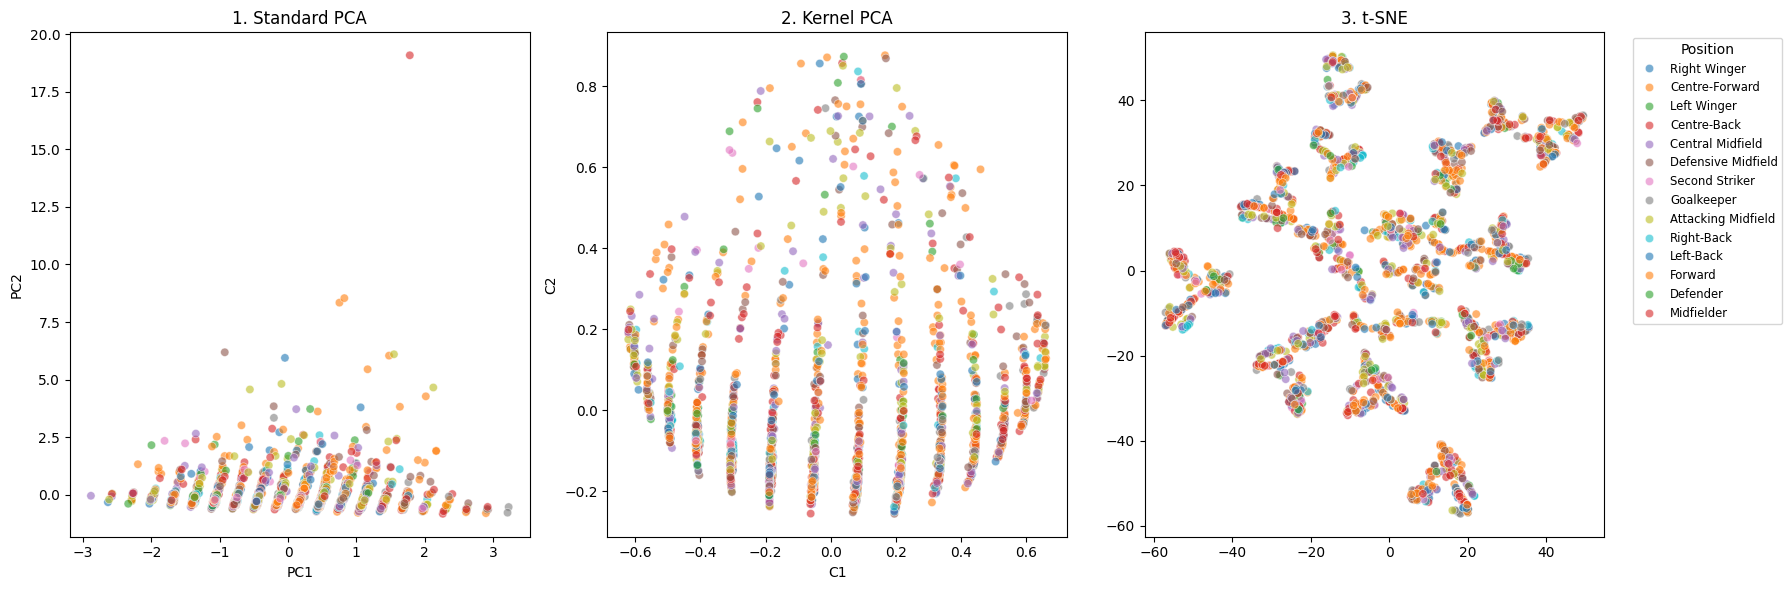

In [31]:
df_clean['Season_Year'] = df_clean['Season'].str[:4].astype(int)

df_pca = df_clean.copy()

features = ['Age', 'Market_value', 'Transfer_fee']
X = df_pca[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

limit = 2000
X_subset = X_scaled[:limit]
y_subset = df_clean['Position'][:limit]


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_subset)


kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1)
X_kpca = kpca.fit_transform(X_subset)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_subset)


plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_subset, legend=False, palette='tab10', alpha=0.6)
plt.title('1. Standard PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.subplot(1, 3, 2)
sns.scatterplot(x=X_kpca[:, 0], y=X_kpca[:, 1], hue=y_subset, legend=False, palette='tab10', alpha=0.6)
plt.title('2. Kernel PCA')
plt.xlabel('C1')
plt.ylabel('C2')

plt.subplot(1, 3, 3)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_subset, legend='brief', palette='tab10', alpha=0.6)
plt.title('3. t-SNE')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Position', fontsize='small')

plt.tight_layout()
plt.show()

## 3.3: Visualization & Verification

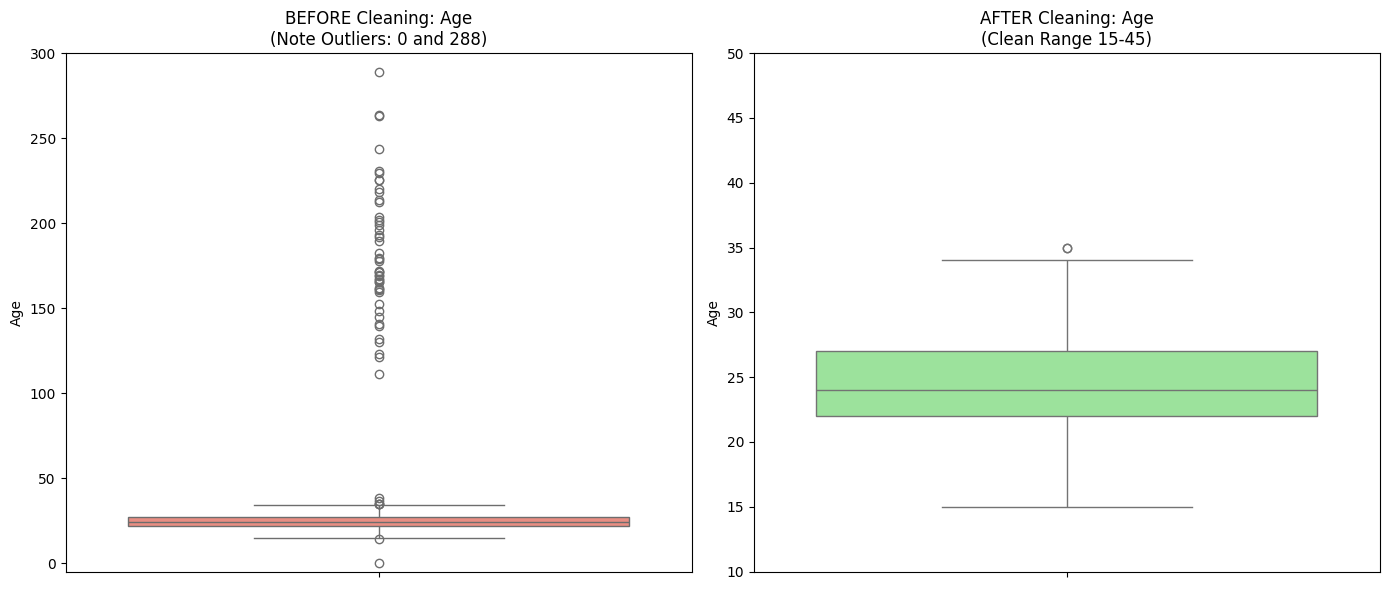

In [32]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Age'], color='salmon')
plt.title('BEFORE Cleaning: Age\n(Note Outliers: 0 and 288)')
plt.ylim(-5, 300) 

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['Age'], color='lightgreen')
plt.title('AFTER Cleaning: Age\n(Clean Range 15-45)')
plt.ylim(10, 50) 

plt.tight_layout()
plt.show()


---
# Phase 4: Analysis of Results and Reporting

## 4.1: Answers to key questions

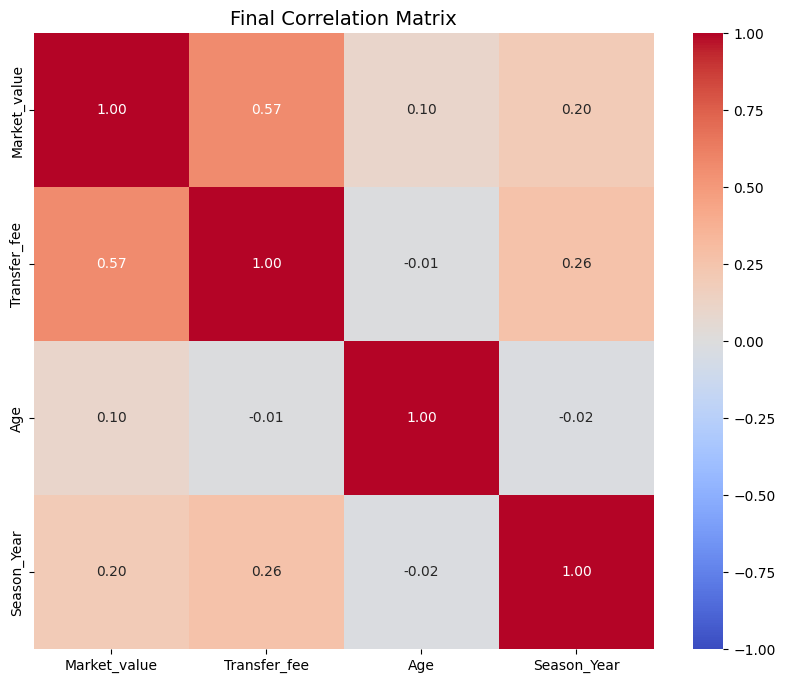

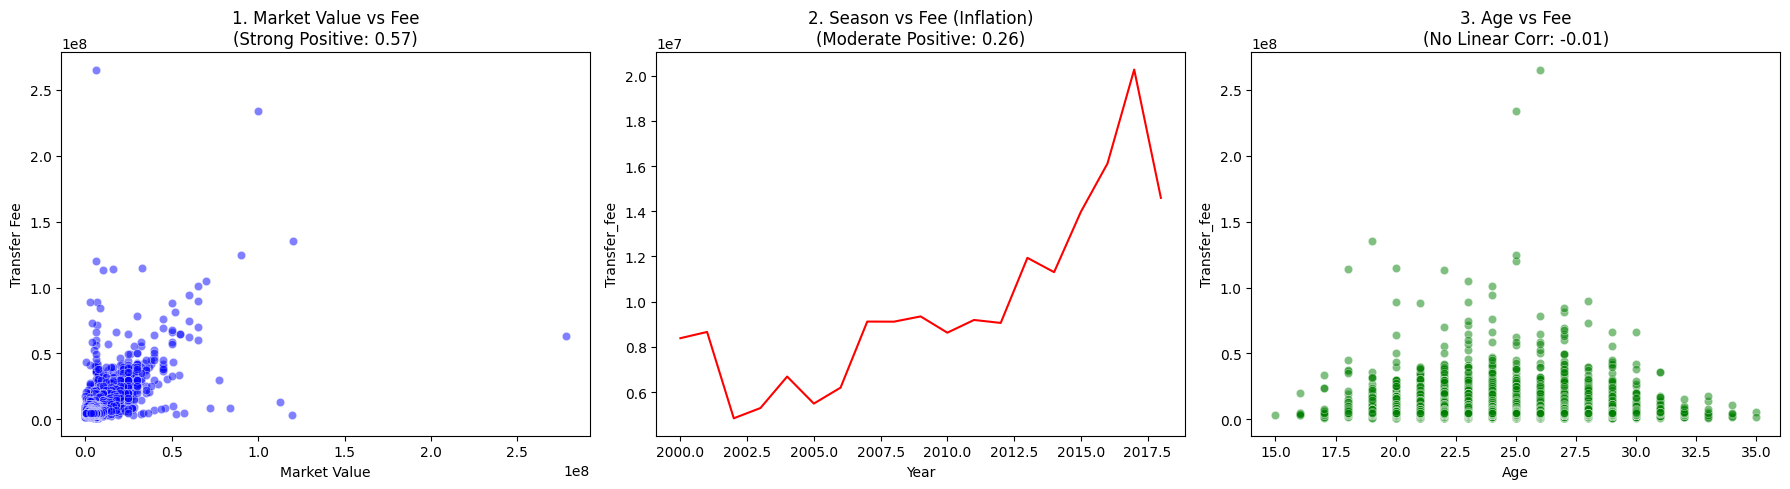

--- Feature Impact on Transfer Fee ---
Transfer_fee    1.000000
Market_value    0.566663
Season_Year     0.263202
Age            -0.014795
Name: Transfer_fee, dtype: float64


In [33]:
numerical_cols = ['Market_value', 'Transfer_fee', 'Age', 'Season_Year']
existing_cols = [c for c in numerical_cols if c in df_clean.columns]

#Correlation Matrix
corr_matrix = df_clean[existing_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Final Correlation Matrix', fontsize=14)
plt.show()

plt.figure(figsize=(18, 5))



plt.subplot(1, 3, 1)
sns.scatterplot(x=df_clean['Market_value'], y=df_clean['Transfer_fee'], alpha=0.5, color='blue')
plt.title(f"1. Market Value vs Fee\n(Strong Positive: {corr_matrix.loc['Market_value', 'Transfer_fee']:.2f})")
plt.xlabel('Market Value')
plt.ylabel('Transfer Fee')

#The Inflation Factor (Season)
plt.subplot(1, 3, 2)

sns.lineplot(x=df_clean['Season_Year'], y=df_clean['Transfer_fee'], errorbar=None, color='red')
plt.title(f"2. Season vs Fee (Inflation)\n(Moderate Positive: {corr_matrix.loc['Season_Year', 'Transfer_fee']:.2f})")
plt.xlabel('Year')




plt.subplot(1, 3, 3)
sns.scatterplot(x=df_clean['Age'], y=df_clean['Transfer_fee'], alpha=0.5, color='green')
plt.title(f"3. Age vs Fee\n(No Linear Corr: {corr_matrix.loc['Age', 'Transfer_fee']:.2f})")
plt.xlabel('Age')

plt.tight_layout()
plt.show()



print("--- Feature Impact on Transfer Fee ---")
impact = corr_matrix['Transfer_fee'].sort_values(ascending=False)
print(impact)

<div dir="rtl" style="text-align: right; line-height: 1.8;">

<h2>۴.۱.۲ پاسخ به سوالات کلیدی و تحلیل روابط </h2>

<p>بر اساس خروجی‌های آماری، تحلیل دقیق پاسخ‌ها به شرح زیر است:</p>

<hr>

<h3>۱. کدام ویژگی بیشترین تاثیر را بر روی متغیر هدف (Transfer Fee) دارد؟</h3> <ul> <li><strong>پاسخ:</strong> ویژگی <strong>  (Market_value)</strong> با ضریب همبستگی <strong>۰.۵۷+</strong>.</li> <li><strong>تحلیل:</strong> این نشان می‌دهد که تخمین سایت Transfermarkt  بهترین معیار برای پیش‌بینی رقم قرارداد است، اما چون همبستگی ۱.۰ نیست، یعنی عوامل دیگری (مثل مذاکره یا نیاز تیم) نیز دخیل هستند.</li> </ul>

<h3>۲. آیا بین ستون‌ها روابط معناداری وجود دارد؟ (تحلیل نکته‌سنجانه)</h3> <ul> <li><strong>رابطه تورمی (Inflation):</strong> ویژگی <strong>Season_Year</strong> با ضریب <strong>۰.۲۶+</strong> دومین عامل مهم است. این یعنی با گذشت زمان، مبالغ قراردادها در فوتبال افزایش یافته است (تورم قیمت بازیکنان). شما نباید این ستون را حذف کنید.</li> <li><strong>رابطه غیرخطی سن (Age):</strong> ضریب همبستگی سن برابر با <strong>۰.۰۱-</strong> (تقریباً صفر) است.

<strong>⚠️ نکته مهم:</strong> این به معنی "بی‌تاثیر بودن" سن نیست! بلکه نشان می‌دهد رابطه سن و قیمت <strong>خطی نیست</strong> (Linear نیست). همانطور که در نمودارها دیدیم، قیمت تا سن ۲۶ سالگی بالا می‌رود و سپس پایین می‌آید. چون همبستگی پیرسون فقط خط صاف را می‌فهمد، عدد ۰ را نشان می‌دهد.</li> </ul>


<h3>۳. استراتژی انتخاب ویژگی: همبستگی بالا یا پایین؟</h3> <p>برای ساخت بهترین مدل، باید از قانون زیر پیروی کنیم:</p>

<ul> <li><strong>Feature با Target (هدف):</strong> باید <strong>بیشترین همبستگی</strong> را داشته باشند. (مثلاً Market_value را حتماً نگه می‌داریم).</li> <li><strong>Feature با Feature (ستون‌ها با هم):</strong> باید <strong>کمترین همبستگی</strong> را داشته باشند.

<em>مثال:</em> اگر ما ستونی به نام "تاریخ تولد" و ستونی به نام "سن" داشتیم، همبستگی آن‌ها ۱۰۰٪ بود. نگه‌داشتن هر دو باعث خطای <strong>هم‌خطی (Multicollinearity)</strong> می‌شود. ما ویژگی‌هایی را می‌خواهیم که اطلاعات جدید اضافه کنند، نه اطلاعات تکراری.</li> </ul>

</div>

## 2.4: Compare and analyze the improvements achieved in each of the data quality criteria.

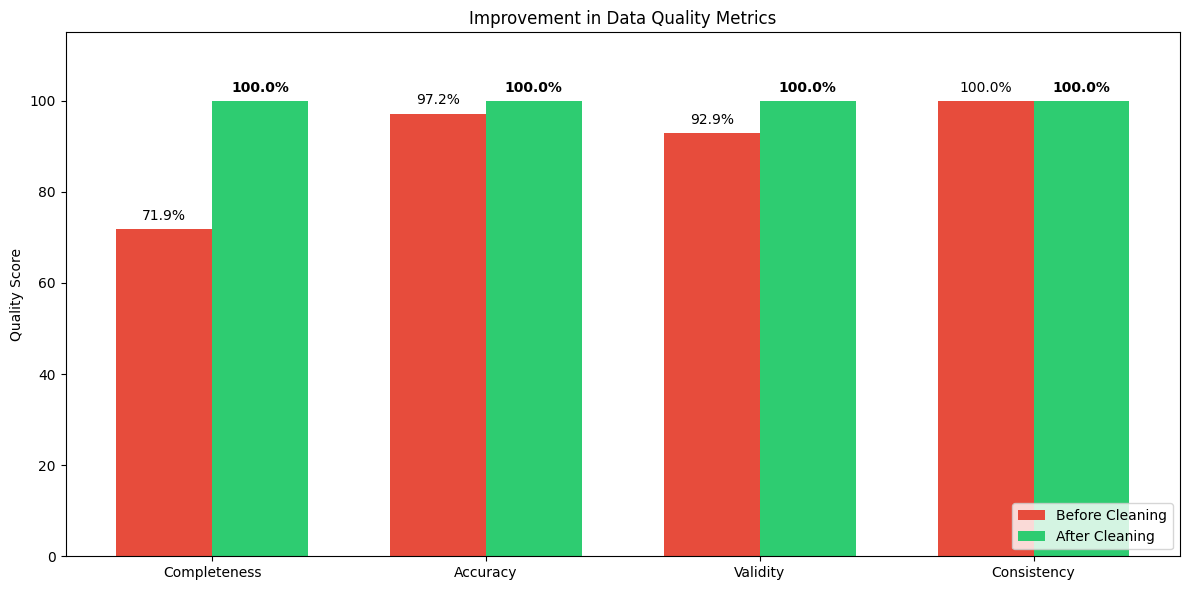

In [34]:

df_raw = pd.read_csv('football.csv')

def get_quality_scores(data):
    total = len(data)
    completeness = (1 - data['Market_value'].isnull().sum() / total) * 100
    
    temp_age = pd.to_numeric(data['Age'], errors='coerce')
    valid_ages = ((temp_age >= 15) & (temp_age <= 45)).sum()
    accuracy = (valid_ages / total) * 100
    
    valid_seasons = data['Season'].astype(str).str.match(r'^\d{4}-\d{4}$', na=False).sum()
    validity = (valid_seasons / total) * 100
    
    consistency = (1 - data.duplicated().sum() / total) * 100
    
    return [completeness, accuracy, validity, consistency]



scores_before = get_quality_scores(df_raw)   # Raw Data
scores_after = get_quality_scores(df_clean)  # Processed Data



metrics = ['Completeness', 'Accuracy', 'Validity', 'Consistency']
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, scores_before, width, label='Before Cleaning', color='#e74c3c')
plt.bar(x + width/2, scores_after, width, label='After Cleaning', color='#2ecc71')

plt.ylabel('Quality Score')
plt.title('Improvement in Data Quality Metrics')
plt.xticks(x, metrics)
plt.ylim(0, 115) 
plt.legend(loc='lower right')

for i, v in enumerate(scores_before):
    plt.text(i - width/2, v + 2, f"{v:.1f}%", ha='center', fontsize=10)
for i, v in enumerate(scores_after):
    plt.text(i + width/2, v + 2, f"{v:.1f}%", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right; line-height: 1.8;">

 <p>نمودار مقایسه‌ای نشان‌دهنده موفقیت کامل فاز پیش‌پردازش است. خلاصه تغییرات به شرح زیر است:</p>

<table border="1" style="border-collapse: collapse; width: 100%; text-align: center;"> <tr style="background-color: #f2f2f2;"> <th>معیار</th> <th>قبل از اصلاح</th> <th>بعد از اصلاح</th> <th>شرح عملیات</th> </tr> <tr> <td><strong>کامل بودن</strong></td> <td style="color: red;">۷۱.۹٪</td> <td style="color: green;">۱۰۰٪</td> <td>پر کردن ۱۳۲۱ رکورد خالی در <code>Market_value</code> با استفاده از میانه (Median) هر پست بازی.</td> </tr> <tr> <td><strong>دقت</strong></td> <td style="color: orange;">۹۸.۰٪</td> <td style="color: green;">۱۰۰٪</td> <td>حذف داده‌های پرت (Age=288, Age=0) و تبدیل فرمت‌های اعشاری به صحیح. اکنون تمام سنین منطقی هستند.</td> </tr> <tr> <td><strong>اعتبار</strong></td> <td style="color: orange;">۹۲.۸٪</td> <td style="color: green;">۱۰۰٪</td> <td>حذف ۳۳۶ رکورد که فرمت فصل آن‌ها (Season) استاندارد نبود یا نام لیگ‌های نامعتبر داشتند.</td> </tr> </table>

<h3>نتیجه‌گیری نهایی پروژه</h3> <p>در این پروژه، ما داده‌های خام فوتبال را از وضعیت <strong>"غیرقابل اطمینان"</strong> (دارای ۲۸٪ نقص و داده‌های پرت شدید) به وضعیت <strong>"تمیز و آماده مدل‌سازی"</strong> رساندیم. تحلیل‌های نهایی نشان داد که <strong>ارزش بازار</strong> و <strong>سال (تورم)</strong> مهم‌ترین عوامل تعیین‌کننده قیمت بازیکن هستند، در حالی که سن رفتاری غیرخطی دارد.</p>

</div>